This is a simple workflow for data correction and averaging of repeated k-space acquisitions.

In these repeated acquisitions, the raw k-space data may not be directly averageable in the complex domain mainly because of phase instability.

Two common problems are:
1. **K-space center shift**  
   The maximum signal (kspace center) may not be located at the matrix center.
2. **Inter-repetition phase inconsistency**  
   Different repetitions may have different global or spatially varying phase due to motion, system drift, or shot-to-shot phase variation.  
   If we simply average complex k-space without phase alignment, signal may cancel out.

Therefore, the pipeline consists of two steps:
1. Phase correction, implemented by aligning the k-space center to the matrix center.
2. Repetition averaging, where repetitions are treated as virtual coils and combined using BART `cc`.

In [1]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
import os

In [ ]:
# import bart
# assume you've already installed bart toolbox
import os
import sys
sys.path.append('/home/bart/python')

from bart import bart
import cfl

Step 0: Define helper functions

In [ ]:
def ifft2c(kspace: np.ndarray) -> np.ndarray:
    """Centred 2-D IFFT over the last two axes. Preserves leading dims."""
    return np.fft.fftshift(
        np.fft.ifft2(
            np.fft.ifftshift(kspace, axes=(-2, -1)),
            axes=(-2, -1),
            norm="ortho", # "ortho" same as * sqrt(N)
        ),
        axes=(-2, -1),
    )

def fft2c(kspace: np.ndarray) -> np.ndarray:
    """Centred 2-D FFT over the last two axes. Preserves leading dims."""
    return np.fft.fftshift(
        np.fft.fft2(
            np.fft.ifftshift(kspace, axes=(-2, -1)),
            axes=(-2, -1),
            norm="ortho",
        ),
        axes=(-2, -1),
    )

def sos(x, dim=0) -> np.ndarray:
    """
    Sum-of-squares over specified dimension.
    """
    return np.sqrt(np.sum(np.abs(x) ** 2, axis=dim))

def show_coils(data, slice_nums, cmap=None):
    fig = plt.figure()
    for i, num in enumerate(slice_nums):
        plt.subplot(1, len(slice_nums), i + 1)
        plt.imshow(data[num], cmap=cmap)

def show_coils_phase(img, coils=[0,1,2,3], cmap='gray'):
    n = len(coils)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

    for i, c in enumerate(coils):
        im = axes[i].imshow(img[c], cmap=cmap, vmin=-np.pi, vmax=np.pi)
        axes[i].set_title(f'coil {c}')
        axes[i].axis('off')

    cbar = fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)

    cbar.set_ticks([-np.pi, 0, np.pi])
    cbar.set_ticklabels([r'$-\pi$', '0', r'$\pi$'])

    plt.tight_layout()
    plt.show()

def find_kspace_centers(kspace):
    ncoil = kspace.shape[0]
    centers = []

    for c in range(ncoil):
        abs_k = np.abs(kspace[c])
        idx = np.unravel_index(np.argmax(abs_k), abs_k.shape)
        centers.append(idx)
        print(f"Coil {c}: max |k| at index {idx}")

    return centers

# shift the kspace center to the middle of the matrix
def shift_kspace_coil_by_coil(kspace):
    """
    kspace: [ncoil, nx, ny]
    Shift each coil independently so its max-|k| moves to matrix center.
    """
    ncoil, nx, ny = kspace.shape
    target = np.array([nx // 2, ny // 2])

    kspace_shifted = np.zeros_like(kspace)
    shifts = []
    centers = []

    for c in range(ncoil):
        abs_k = np.abs(kspace[c])
        center = np.array(np.unravel_index(np.argmax(abs_k), abs_k.shape))
        shift = target - center

        kspace_shifted[c] = np.roll(kspace[c], shift=tuple(shift), axis=(-2, -1))
        centers.append(center)
        shifts.append(shift)

        print(f"Coil {c}: center = {tuple(center)}, shift = {tuple(shift)}")

    return kspace_shifted, np.array(centers), np.array(shifts)

# To shift the k-space center, it is more common to apply the same shift to all coils instead of one-by one
# So we can use the coil with the strongest signal to determine such a shift
def shift_kspace_same_shift_all_coils(kspace):
    """
    kspace: [ncoil, nx, ny]

    Determine k-space center from the coil with the strongest signal,
    then apply the same shift to all coils.

    This preserves the intrinsic phase difference between coils.
    """
    ncoil, nx, ny = kspace.shape
    target = np.array([nx // 2, ny // 2])

    coil_energy = np.sum(np.abs(kspace) ** 2, axis=(-2, -1))
    ref_coil = np.argmax(coil_energy)

    abs_k = np.abs(kspace[ref_coil])
    center = np.array(np.unravel_index(np.argmax(abs_k), abs_k.shape))
    shift = target - center

    kspace_shifted = np.roll(kspace, shift=tuple(shift), axis=(-2, -1))

    print(f"Reference coil: {ref_coil}")
    print(f"Detected center: {tuple(center)}")
    print(f"Applied same shift to all coils: {tuple(shift)}")

    return kspace_shifted, ref_coil, center, shift

Step 1: shift the kspace center to matrix center

(4, 256, 256) complex64


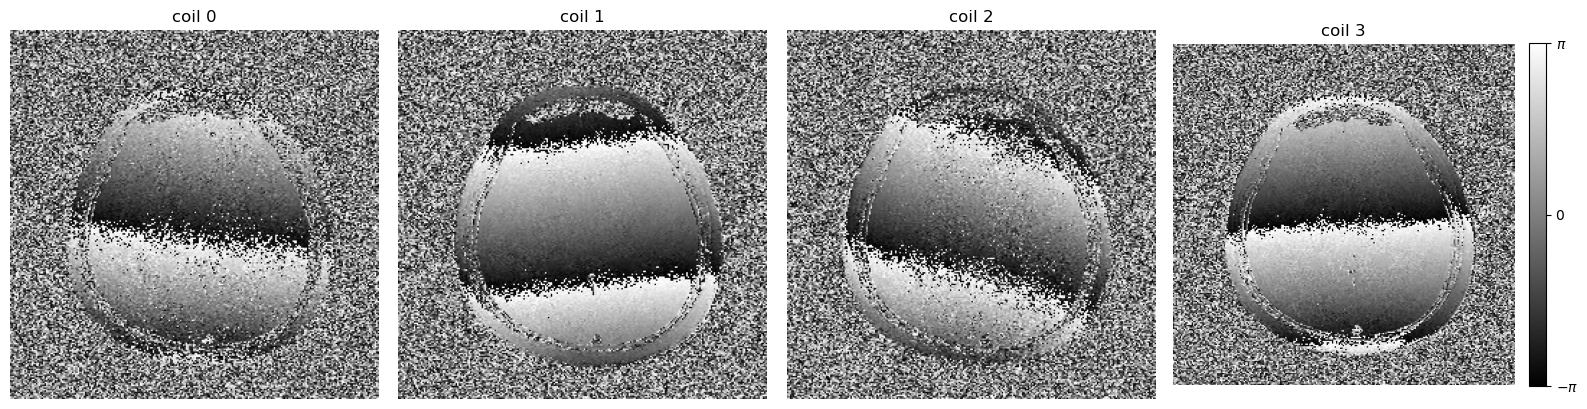

In [ ]:
# load example data
data_folder = ' ' # please change this to your data folder

file_name = os.path.join(data_folder, '2022061001_T201.h5')
hf1 = h5py.File(file_name)
volume_kspace = hf1['kspace'][()] # first scan
slice_kspace = volume_kspace[8]

print(slice_kspace.shape, slice_kspace.dtype)

image_before_shift = ifft2c(slice_kspace)
phase_before_shift = np.angle(image_before_shift)
show_coils_phase(phase_before_shift)

Coil 0: center = (125, 128), shift = (3, 0)
Coil 1: center = (125, 128), shift = (3, 0)
Coil 2: center = (125, 129), shift = (3, -1)
Coil 3: center = (125, 128), shift = (3, 0)


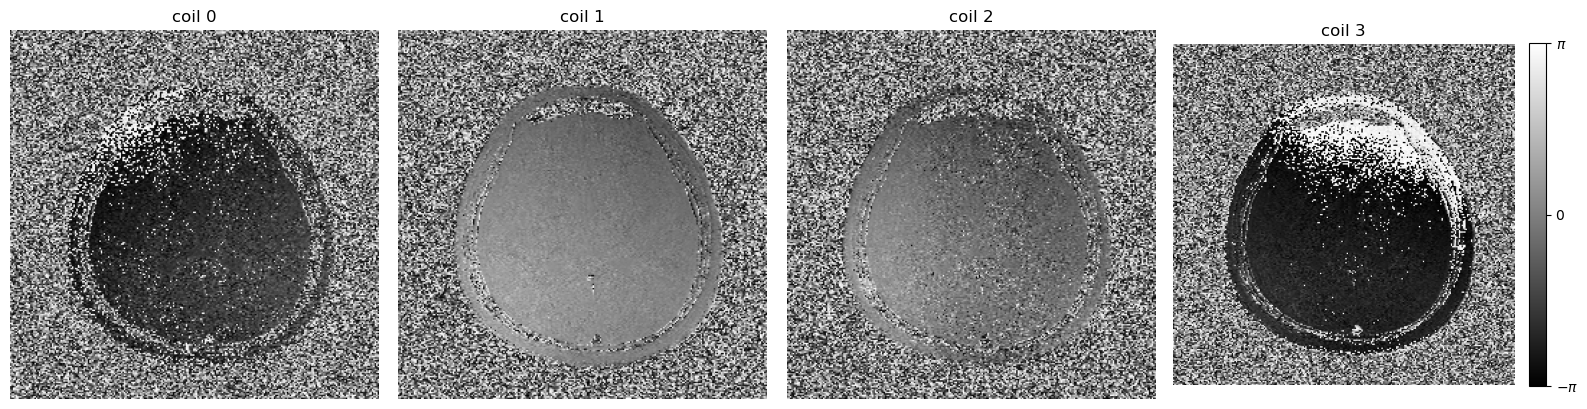

In [ ]:
# phase correction
# slice_kspace_shifted, _, _ = shift_kspace_coil_by_coil(slice_kspace)
slice_kspace_shifted, _, _, _ = shift_kspace_same_shift_all_coils(slice_kspace)

image_after_shift = ifft2c(slice_kspace_shifted)
phase_after_shift = np.angle(image_after_shift)
show_coils_phase(phase_after_shift)


Step 2: combine the average ksapce

In [11]:
# load example data
file_name1 = os.path.join(data_folder, '2022061001_T201.h5')
hf1 = h5py.File(file_name1)
volume_kspace1 = hf1['kspace'][()] # first scan
slice_kspace1 = volume_kspace1[8]

file_name2 = os.path.join(data_folder, '2022061001_T202.h5')
hf2 = h5py.File(file_name2)
volume_kspace2 = hf2['kspace'][()] # second scan
slice_kspace2 = volume_kspace2[8]

file_name3 = os.path.join(data_folder, '2022061001_T203.h5')
hf3 = h5py.File(file_name3)
volume_kspace3 = hf3['kspace'][()] # third scan
slice_kspace3 = volume_kspace3[8]

kspace_reps = np.stack([slice_kspace1, slice_kspace2, slice_kspace3], axis=0) # [nrep, ncoil, nx, ny]

print(kspace_reps.shape, kspace_reps.dtype)

(3, 4, 256, 256) complex64


In [20]:
def bart_cc_average_repetitions(kspace_reps_slice, ncc=1):
    """
    Compress repetitions for one slice using BART cc.

    For each physical coil separately, treat repetitions as virtual coils
    and compress them with `bart cc -p {ncc}`.

    Args:
        kspace_reps_slice: complex array, shape [nrep, ncoil, nx, ny]
        ncc: number of compressed repetition channels to keep

    Returns:
        If ncc == 1:
            complex64 array, shape [ncoil, nx, ny]
        Else:
            complex64 array, shape [ncoil, ncc, nx, ny]
    """
    if kspace_reps_slice.ndim != 4:
        raise ValueError(
            f"Expected shape [nrep, ncoil, nx, ny], got {kspace_reps_slice.shape}"
        )

    nrep, ncoil, nx, ny = kspace_reps_slice.shape
    out = []

    for c in range(ncoil):
        # [nrep, nx, ny] -> [nx, ny, 1, nrep]
        ksp_bart = np.transpose(kspace_reps_slice[:, c], (1, 2, 0))[:, :, None, :].astype(np.complex64)

        # BART cc output: [nx, ny, ncc], if ncc=1 then [nx, ny]
        ksp_cc = np.asarray(bart(1, f"cc -p {ncc}", ksp_bart), dtype=np.complex64)

        out.append(ksp_cc)   # [nx, ny]

    return np.stack(out, axis=0)

(256, 256)
(256, 256)
Done.
Done.
Done.
Done.
(256, 256)


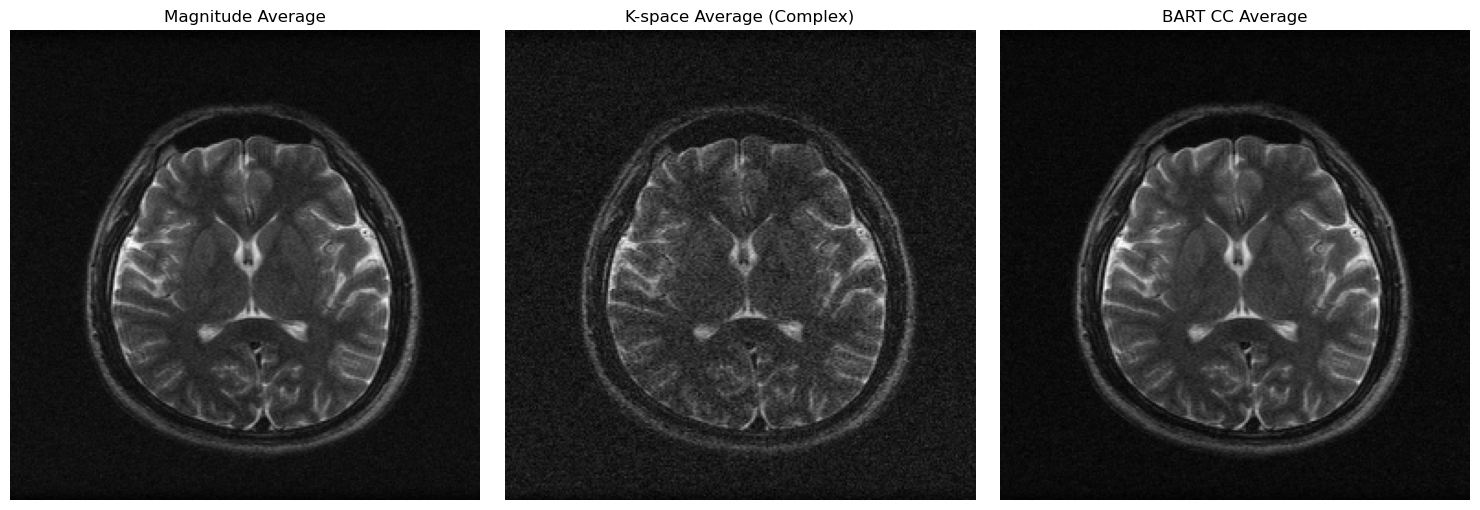

In [ ]:
# average magnitudes 
imgs = [ifft2c(kspace_reps[r]) for r in range(kspace_reps.shape[0])]
sos_imgs = [sos(img, dim=0) for img in imgs]
img_mag_avg = np.mean(sos_imgs, axis=0)   # [nx, ny]

# average ksapce
kspace_avg = np.mean(kspace_reps, axis=0)   # [ncoil, nx, ny]
img_ksp_avg = sos(ifft2c(kspace_avg), dim=0) # [nx, ny]

# average ksapce using bart coil compresion (treat different as virtual coils)
ksp_cc_avg = bart_cc_average_repetitions(kspace_reps)
img_cc_avg = sos(ifft2c(ksp_cc_avg), dim=0)

# visualization
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_mag_avg, cmap='gray')
plt.title('Magnitude Average')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_ksp_avg, cmap='gray')
plt.title('K-space Average (Complex)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_cc_avg, cmap='gray')
plt.title('BART CC Average')
plt.axis('off')

plt.tight_layout()
plt.show()

In this way, the average image is complex (better for MRI reconstruction), we can also plot the phase together.

In [ ]:
image_cc_avg = ifft2c(ksp_cc_avg)
phase_cc_avg = np.angle(image_cc_avg)

show_coils_phase(phase_cc_avg, coils=[0, 1, 2, 3])